# Taller de Visualización de Datos con Python
## Análisis de dataset: Novel Corona Virus 2019

**Objetivos:**
- Identificar y aplicar técnicas de visualización adecuadas según el tipo de dato (categórico, continuo, temporal).

- Analizar distribuciones de datos mediante histogramas, polígonos de frecuencia y diagramas de caja.

- Crear visualizaciones avanzadas (mapas de calor geográficos) para comunicar hallazgos complejos.

**Instrucciones:**
- Trabajen en grupos de 3 estudiantes
- Tiempo disponible: 2 horas
- Entreguen un notebook de Jupyter con el código y respuestas a las preguntas
- Incluyan comentarios explicando su proceso de análisis

**Dataset:** `covid_19_data.csv` - Dataset global de COVID-19 que incluye casos confirmados, muertes y recuperaciones por país y fecha, desde enero de 2020

---

## Actividad 1: Carga y Exploración Inicial del Dataset (15 minutos)

1.	Cargar el dataset COVID-19 Global.

- Navegar a https://www.kaggle.com/datasets/sudalairajkumar/novel-corona-virus-2019-dataset/data
- Revisar la descripción de las columnas del dataset
- Dar click en el botón: '<> Code' para desplegar el código necesario para importar el dataset.
- Copiar el código y pegarlo en el Jupiter Notebook.
- Modifique la variable file_path así: file_path="covid_19_data.csv"
- Ejecute el código y tendrá el dataset importado en la variable df

2.	Realizar una exploración inicial para entender la estructura del dataset.
3.	Preparar los datos para el análisis (conversión de tipos, manejo de valores nulos, etc.).

---

## Actividad 2: Visualizaciones Básicas (35 minutos)

1.	Gráfico de Barras:
*	Representen los 10 países con mayor número de casos confirmados.
*	Creen un gráfico de barras comparando muertes y recuperados para los 5 países más afectados.
* ¿Qué pueden concluir acerca de los países más afectados y los datos reportados acerca de muertes y recuperados?

- NOTA: Tenga en cuenta que las columnas Confirmed, Deaths, Recovered son acumulativas, es decir que en cada dato que aparece se consolidan los datos de los días anteriores. También es normal que los valores máximos de casos Confirmados no coincidan con los valores máximos de Muertes o Recuperados

2.	Gráfico de Líneas:
*	Visualicen la evolución temporal de casos confirmados, muertes y recuperados a nivel global.
* ¿Qué pueden observar acerca del comportamiento de los datos?

3.	Histograma y Polígono de Frecuencia:
*	Creen un histograma de la distribución de casos confirmados en Estados Unidos.
*	Generen tres polígonos de frecuencia, superpuestos, mostrando la distribución de casos confirmados para Francia, Brasil y Turquía.
*	¿Qué pueden concluir acerca de las distribuciones?

---

## ACTIVIDAD 3: Visualizaciones Estadísticas (35 minutos)

1.	Diagrama de Dispersión:
*	Crear un diagrama de dispersión entre casos confirmados y muertes. (No incluya países con menos de 1000 casos confirmados)
*	Calcular la correlación entre ambas variables.
* ¿Cómo se relacionan las variables?

2.	Diagrama de Caja y Bigotes:
*	Cree diagramas de cajas para la distribución de casos confirmados en los países sudamericanos
* ¿Qué países presentan valores atípicos?¿Qué puede concluir al respecto y acerca de los datos?
* NOTA: Use escala logarítmica para visualizar mejor

3.	Diagrama Cuantil-Cuantil:
*	Creen el diagrama Cuantil-Cuantil utilizando los Casos confirmados.
* Creen otro diagrama Cuantil-Cuantil en escala logarítmica para Casos confirmados.
* ¿Cómo se comportan los datos reales en comparación con las líneas teóricas?
* NOTA: Utilicen la función probplot de la librería scipy.stats

---

## ACTIVIDAD 4: Análisis Visual Avanzado (35 minutos)

1.	Mapa de Calor de Correlación:
*	Crear un mapa de calor de correlación entre todas las variables numéricas del dataset.
* ¿Cuál es la correlación más fuerte?

2. Mapa de Calor Geográfico:
*	Crear un mapa de calor geográfico mostrando cantidad de muertes por país
* ¿Qué puede concluir acerca del gráfico?
* NOTA: Utilice la librería plotly.express, función cloropeth. Recuerde agrupar los datos por fecha y país, y sumar las otras categorías para hallar los datos reales.

---

## Discusión y Conclusiones (Tiempo restante)

Basándose en todas las visualizaciones generadas, escriban las 3 conclusiones más importantes que se pueden extraer de los datos.

---

**Entrega:**
- Notebook de Jupyter con: Nombres de integrantes, código, resultados, respuestas


# **Desarrollo**

## Actividad 1: Carga y Exploración Inicial del Dataset


In [4]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "covid_19_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sudalairajkumar/novel-corona-virus-2019-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_19627/744701209.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'novel-corona-virus-2019-dataset' dataset.
First 5 records:    SNo ObservationDate Province/State  Country/Region      Last Update  \
0    1      01/22/2020          Anhui  Mainland China  1/22/2020 17:00   
1    2      01/22/2020        Beijing  Mainland China  1/22/2020 17:00   
2    3      01/22/2020      Chongqing  Mainland China  1/22/2020 17:00   
3    4      01/22/2020         Fujian  Mainland China  1/22/2020 17:00   
4    5      01/22/2020          Gansu  Mainland China  1/22/2020 17:00   

   Confirmed  Deaths  Recovered  
0        1.0     0.0        0.0  
1       14.0     0.0        0.0  
2        6.0     0.0        0.0  
3        1.0     0.0        0.0  
4        0.0     0.0        0.0  


In [5]:
import pandas as pd

print("\n--- Initial Data Exploration ---\n")

# Display basic information about the DataFrame
print("DataFrame Info:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Display unique values for key categorical columns
print("\nUnique Countries/Regions:", df['Country/Region'].nunique())
print("Unique Province/States (top 10):", df['Province/State'].value_counts().head(10))

print("\n--- Data Preparation ---\n")

# Convert 'ObservationDate' to datetime objects
df['ObservationDate'] = pd.to_datetime(df['ObservationDate'])
print("Converted 'ObservationDate' to datetime.")

# Convert 'Confirmed', 'Deaths', 'Recovered' to numeric, coercing errors and filling NaNs with 0
# Errors are coerced to NaN, then NaNs are filled with 0, as missing counts can be interpreted as zero.
for col in ['Confirmed', 'Deaths', 'Recovered']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
print("Converted 'Confirmed', 'Deaths', 'Recovered' to numeric and filled NaNs with 0.")

# Verify changes after data preparation
print("\n--- Data Info After Preparation ---\n")
df.info()

print("\nFirst 5 records after preparation:")
print(df.head())


--- Initial Data Exploration ---

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306429 entries, 0 to 306428
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   SNo              306429 non-null  int64  
 1   ObservationDate  306429 non-null  object 
 2   Province/State   228326 non-null  object 
 3   Country/Region   306429 non-null  object 
 4   Last Update      306429 non-null  object 
 5   Confirmed        306429 non-null  float64
 6   Deaths           306429 non-null  float64
 7   Recovered        306429 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 18.7+ MB

Descriptive Statistics:
                 SNo     Confirmed         Deaths     Recovered
count  306429.000000  3.064290e+05  306429.000000  3.064290e+05
mean   153215.000000  8.567091e+04    2036.403268  5.042029e+04
std     88458.577156  2.775516e+05    6410.938048  2.015124e+05
min         1.000000 -3.0

## Actividad 2: Visualizaciones Básicas

### 1. Gráfico de Barras: Los 10 países con mayor número de casos confirmados.

/tmp/ipykernel_19627/2409248298.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Confirmed', y='Country/Region', data=top_10_confirmed, palette='viridis')


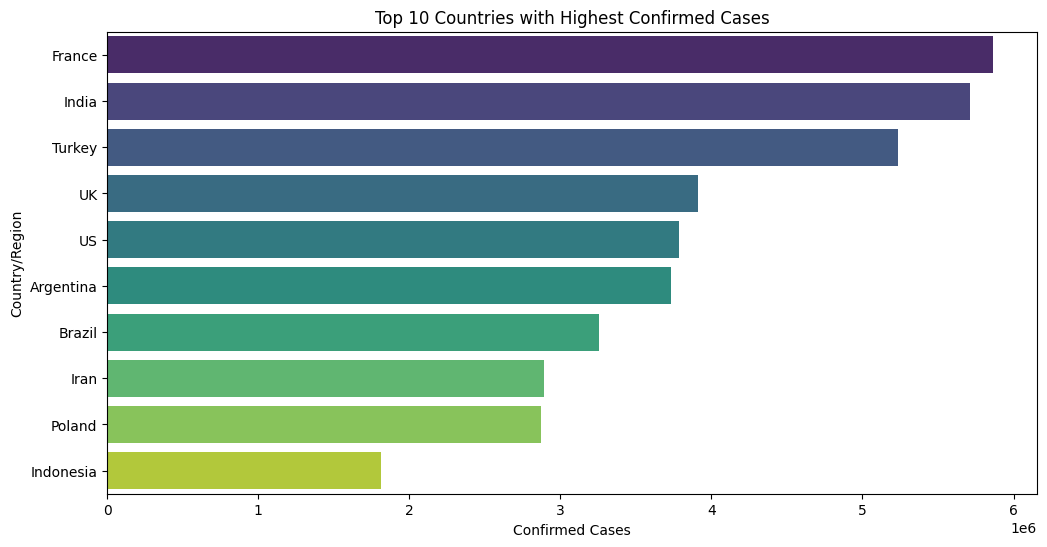

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by country and get the maximum confirmed cases for each country over time
# Since Confirmed is cumulative, the maximum value for each country will be the total confirmed cases.
top_10_confirmed = df.groupby('Country/Region')['Confirmed'].max().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Confirmed', y='Country/Region', data=top_10_confirmed, palette='viridis')
plt.title('Top 10 Countries with Highest Confirmed Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Country/Region')
plt.show()

### Creen un gráfico de barras comparando muertes y recuperados para los 5 países más afectados.

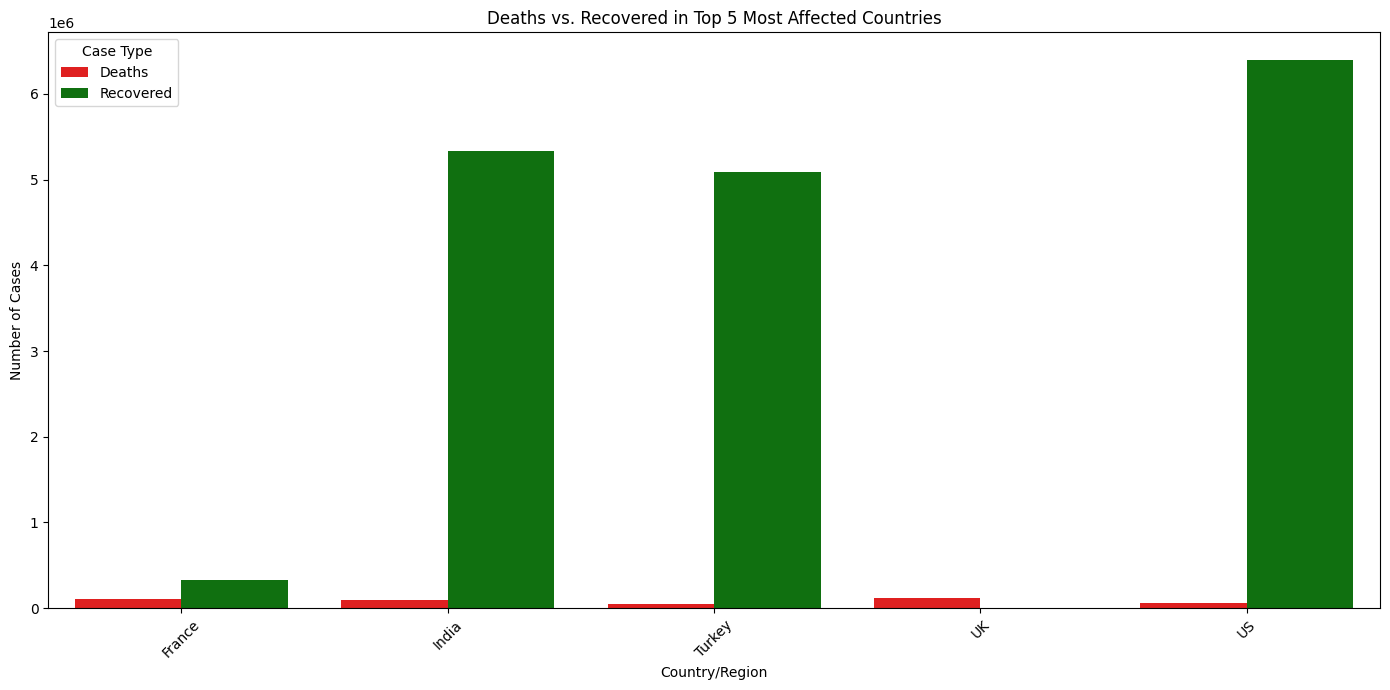

Pregunta: ¿Qué pueden concluir acerca de los países más afectados y los datos reportados acerca de muertes y recuperados?
Respuesta: Estados unidos (US), Turkia (Turkey), e India tuvieron el mayor numero de recuperados y bajas muertes, mientras que Francia y UK tuvieron el mayor numero de muertes y UK el menor numero de recuperados


In [8]:
# To find the 5 most affected countries, we can use the 'top_10_confirmed' DataFrame we already created and take the top 5 from there.
top_5_countries = top_10_confirmed.head(5)['Country/Region'].tolist()

# Filter the original DataFrame for these top 5 countries
df_top_5 = df[df['Country/Region'].isin(top_5_countries)]

# Get the latest cumulative data for these countries
latest_data_top_5 = df_top_5.groupby('Country/Region')[['Deaths', 'Recovered']].max().reset_index()

# Melt the DataFrame to prepare for a grouped bar chart with Seaborn
melted_data = latest_data_top_5.melt(id_vars='Country/Region', var_name='Case Type', value_name='Count')

plt.figure(figsize=(14, 7))
sns.barplot(x='Country/Region', y='Count', hue='Case Type', data=melted_data, palette={'Deaths': 'red', 'Recovered': 'green'})
plt.title('Deaths vs. Recovered in Top 5 Most Affected Countries')
plt.xlabel('Country/Region')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45)
plt.legend(title='Case Type')
plt.tight_layout()
plt.show()

print("Pregunta: ¿Qué pueden concluir acerca de los países más afectados y los datos reportados acerca de muertes y recuperados?")
print("Respuesta: Estados unidos (US), Turkia (Turkey), e India tuvieron el mayor numero de recuperados y bajas muertes, mientras que Francia y UK tuvieron el mayor numero de muertes y UK el menor numero de recuperados")

### 2. Gráfico de Líneas: Evolución temporal de casos confirmados, muertes y recuperados a nivel global.

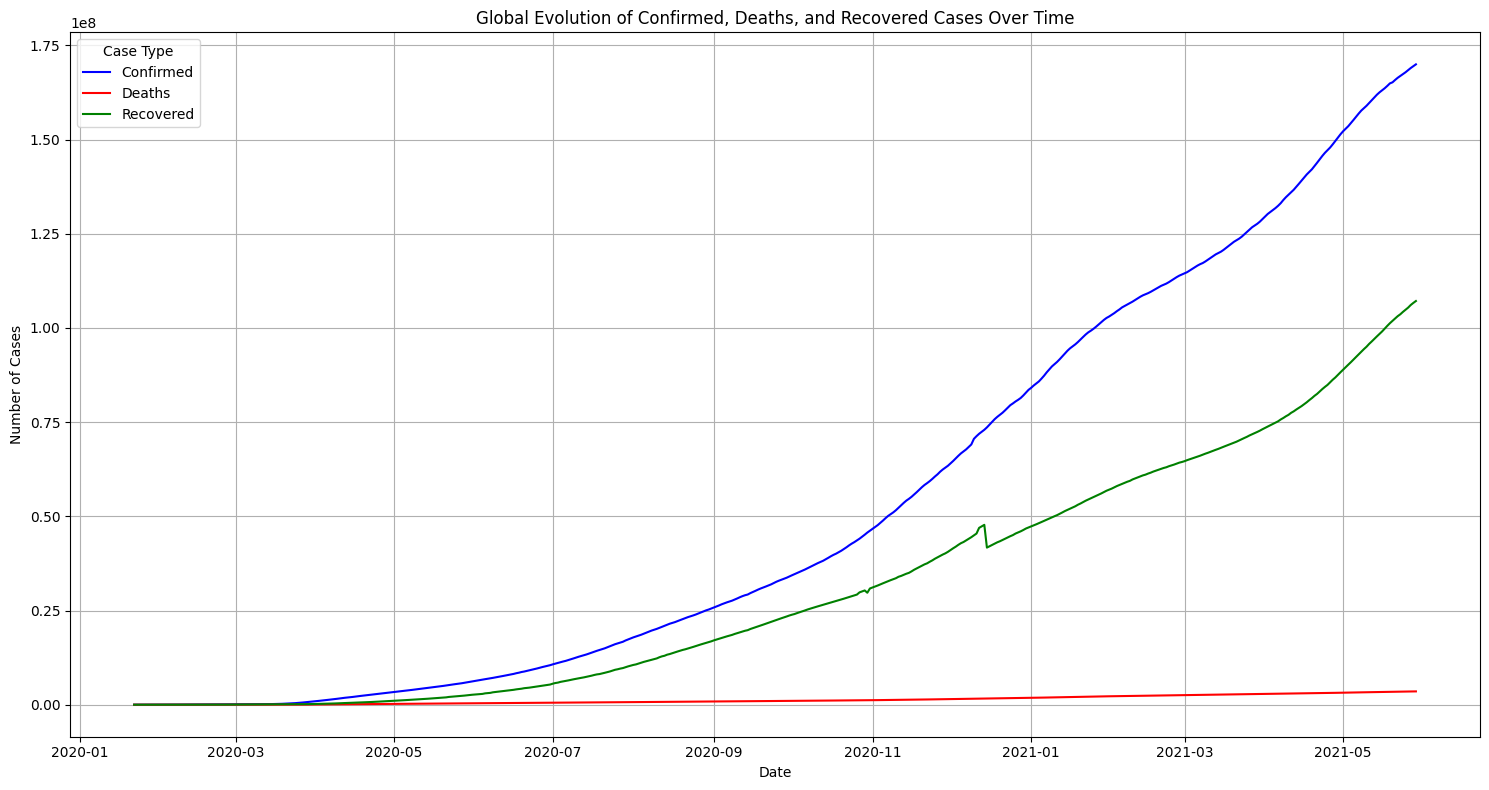

Pregunta: ¿Qué pueden observar acerca del comportamiento de los datos?
Respuesta: A nivel global segun el grafico hubo mayor numero de casos confirmados en aumento, seguido por los casos de recuperacion la cual tambien tuvo una lijera caida entre 2020-11 y 2021-01 aunque se mantubo en aumento mayormente, mientras que avanzan mas despacio las muertes en comparacion con los casos de confirmado y recuperado.


In [11]:
# Group by ObservationDate to get global daily totals
global_data = df.groupby('ObservationDate')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

# Melt the DataFrame to prepare for plotting with seaborn
global_melted_data = global_data.melt(id_vars='ObservationDate', var_name='Case Type', value_name='Count')

plt.figure(figsize=(15, 8))
sns.lineplot(x='ObservationDate', y='Count', hue='Case Type', data=global_melted_data, palette={'Confirmed': 'blue', 'Deaths': 'red', 'Recovered': 'green'})
plt.title('Global Evolution of Confirmed, Deaths, and Recovered Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.grid(True)
plt.legend(title='Case Type')
plt.tight_layout()
plt.show()

print("Pregunta: ¿Qué pueden observar acerca del comportamiento de los datos?")
print("Respuesta: A nivel global segun el grafico hubo mayor numero de casos confirmados en aumento, seguido por los casos de recuperacion la cual tambien tuvo una lijera caida entre 2020-11 y 2021-01 aunque se mantubo en aumento mayormente, mientras que avanzan mas despacio las muertes en comparacion con los casos de confirmado y recuperado.")

### 3. Histograma y Polígono de Frecuencia:

*   Histograma de la distribución de casos confirmados en Estados Unidos.
*   Polígonos de frecuencia superpuestos para Francia, Brasil y Turquía.

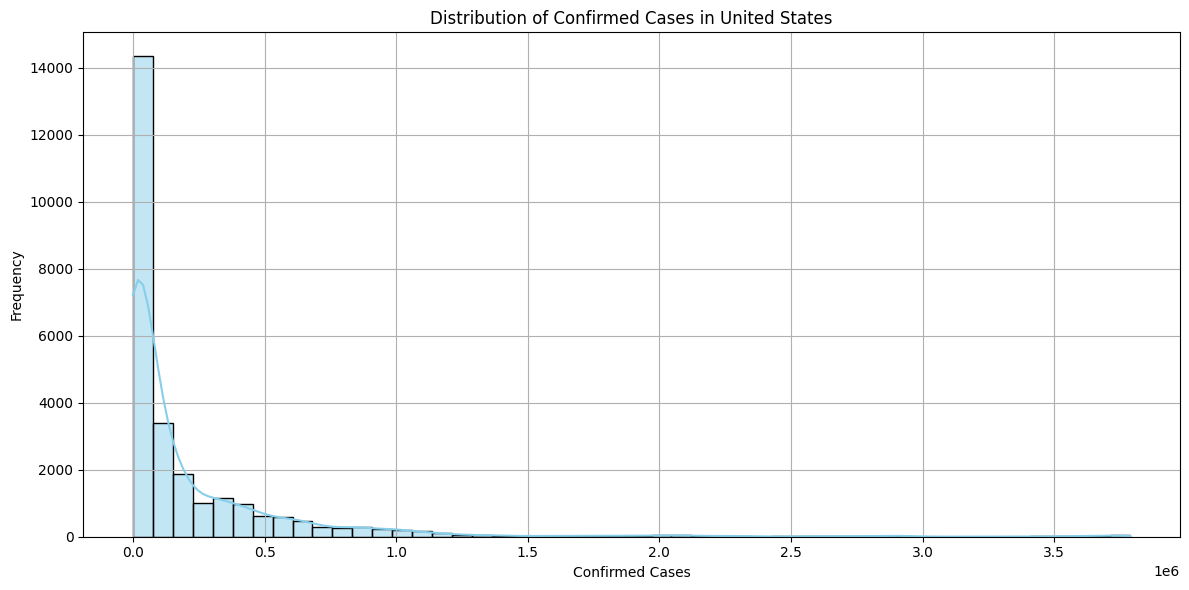

Histograma: ¿Qué pueden concluir acerca de la distribución de casos confirmados en Estados Unidos?
Respuesta: En los 0.0 casos es donde la frecuencia mas abunda llegando a pasar los 14000, y va en un descenso drastico antes de llegar a la confirmacion 0.5, desde la cual continua su descenso hasta que en 1.5 tiene ya una frecuencia cercana a 0, con la cual continua en 0 para mayor numero de casos confirmados.


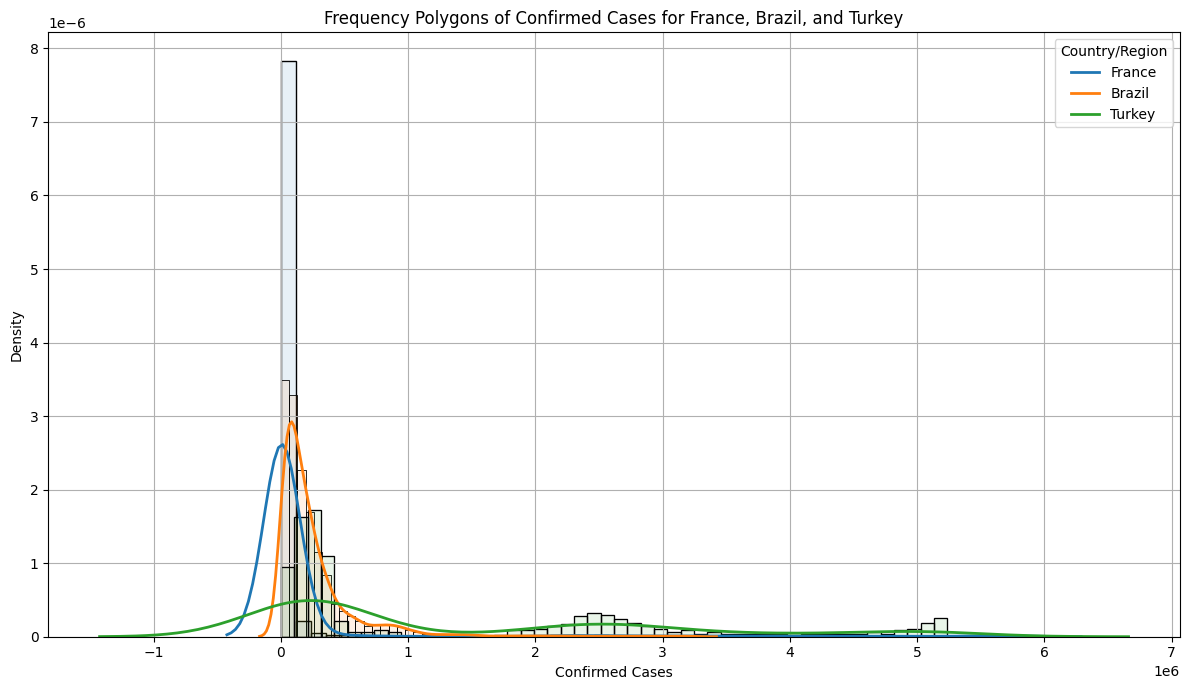

Polígonos de Frecuencia: ¿Qué pueden concluir acerca de las distribuciones de casos confirmados en estos países?
Respuesta: En el rango de los 0 casos confirmados es donde hay mayor densidad llegando a casi 8 de densidad, la cual baja drasticamente a 0 entre 1-2 casos confirmados, pero, vuelve a subir un poco al llegar a los 2-3 casos confirmados, de 3 a 4 casos confirmados vuelve a disminuir, mientras que de de 4 a 5 casos confirmados aumenta la densidad lijeramente para desplomarse a 0 densidad poco despues de pasar de 5 a 6 casos confirmados.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for the United States
df_us = df[df['Country/Region'] == 'US']

# Histogram for Confirmed Cases in the United States
plt.figure(figsize=(12, 6))
sns.histplot(df_us['Confirmed'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Confirmed Cases in United States')
plt.xlabel('Confirmed Cases')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Histograma: ¿Qué pueden concluir acerca de la distribución de casos confirmados en Estados Unidos?")
print("Respuesta: En los 0.0 casos es donde la frecuencia mas abunda llegando a pasar los 14000, y va en un descenso drastico antes de llegar a la confirmacion 0.5, desde la cual continua su descenso hasta que en 1.5 tiene ya una frecuencia cercana a 0, con la cual continua en 0 para mayor numero de casos confirmados.")

# Frequency Polygons for Confirmed Cases in France, Brazil, and Turkey
countries_for_polygon = ['France', 'Brazil', 'Turkey']
df_filtered_polygon = df[df['Country/Region'].isin(countries_for_polygon)]

plt.figure(figsize=(12, 7))
for country in countries_for_polygon:
    # Get the Confirmed cases for the current country
    country_data = df_filtered_polygon[df_filtered_polygon['Country/Region'] == country]['Confirmed']

    # Generate a histogram and then plot the frequency polygon using kdeplot for smoothing
    sns.histplot(country_data, bins=50, kde=False, stat='density', alpha=0.1)
    sns.kdeplot(country_data, label=country, linewidth=2)

plt.title('Frequency Polygons of Confirmed Cases for France, Brazil, and Turkey')
plt.xlabel('Confirmed Cases')
plt.ylabel('Density')
plt.legend(title='Country/Region')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Polígonos de Frecuencia: ¿Qué pueden concluir acerca de las distribuciones de casos confirmados en estos países?")
print("Respuesta: En el rango de los 0 casos confirmados es donde hay mayor densidad llegando a casi 8 de densidad, la cual baja drasticamente a 0 entre 1-2 casos confirmados, pero, vuelve a subir un poco al llegar a los 2-3 casos confirmados, de 3 a 4 casos confirmados vuelve a disminuir, mientras que de de 4 a 5 casos confirmados aumenta la densidad lijeramente para desplomarse a 0 densidad poco despues de pasar de 5 a 6 casos confirmados.")

## ACTIVIDAD 3: Visualizaciones Estadísticas

### 1. Diagrama de Dispersión:

/tmp/ipykernel_19627/2685513080.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


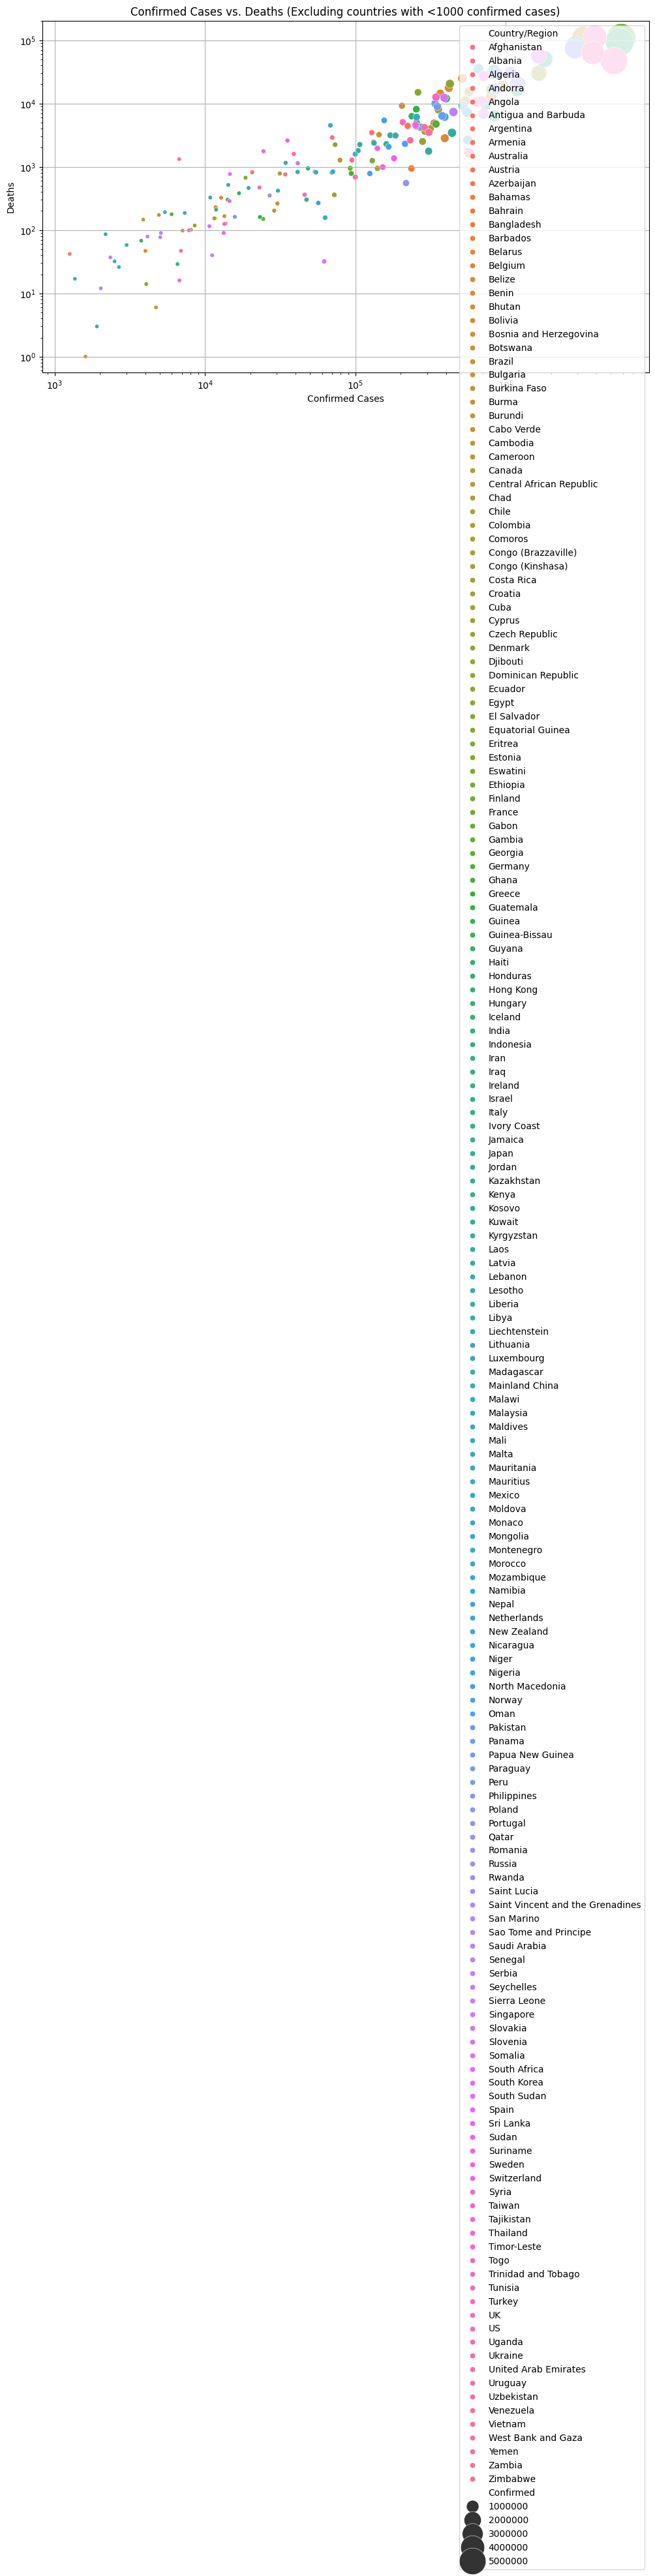

Correlación entre Casos Confirmados y Muertes: 0.92
Pregunta: ¿Cómo se relacionan las variables?
Respuesta: La relacion de las variables: muertes y casos confirmados es directa, donde entre mas casos confirmados hay es donde mas muertes habran segun la grafica.


In [15]:
# Group by country to get the latest confirmed and deaths figures
# The task asks to exclude countries with less than 1000 confirmed cases
df_scatter = df.groupby('Country/Region')[['Confirmed', 'Deaths']].max().reset_index()
df_scatter = df_scatter[df_scatter['Confirmed'] >= 1000]

# Create the scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Confirmed', y='Deaths', data=df_scatter, hue='Country/Region', size='Confirmed', sizes=(20, 1000), legend='brief')
plt.title('Confirmed Cases vs. Deaths (Excluding countries with <1000 confirmed cases)')
plt.xlabel('Confirmed Cases')
plt.ylabel('Deaths')
plt.xscale('log') # Use log scale for better visualization due to large range
plt.yscale('log') # Use log scale for better visualization due to large range
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate the correlation between Confirmed and Deaths
correlation = df_scatter['Confirmed'].corr(df_scatter['Deaths'])
print(f"Correlación entre Casos Confirmados y Muertes: {correlation:.2f}")

print("Pregunta: ¿Cómo se relacionan las variables?")
print("Respuesta: La relacion de las variables: muertes y casos confirmados es directa, donde entre mas casos confirmados hay es donde mas muertes habran segun la grafica.")

### 2. Diagrama de Caja y Bigotes: Casos confirmados en países sudamericanos.

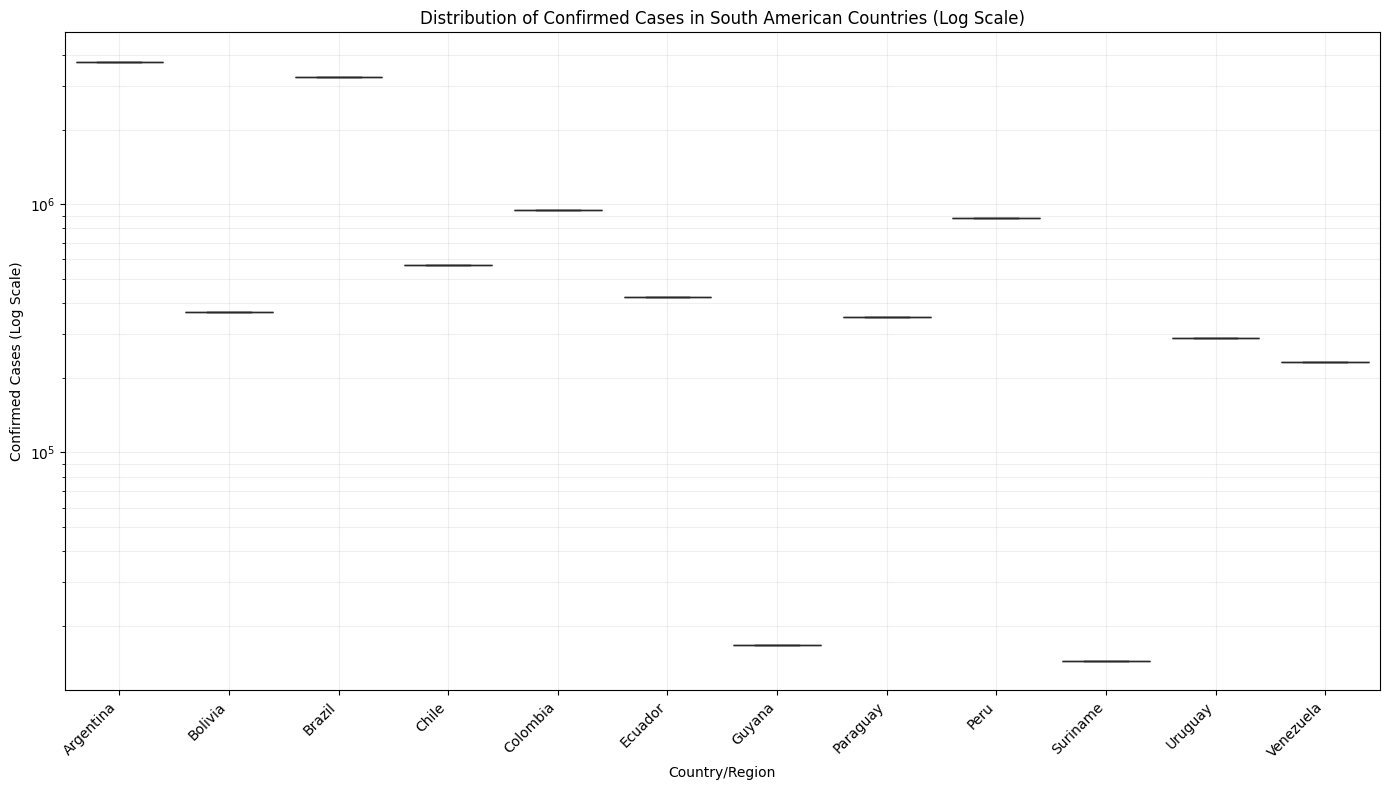

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

south_american_countries = [
    'Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador',
    'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela'
]

df_south_america = df[df['Country/Region'].isin(south_american_countries)]

# Get the latest confirmed cases for each country
# We take the max of confirmed cases per country to represent the total cases for that country over time
latest_confirmed_sa = df_south_america.groupby('Country/Region')['Confirmed'].max().reset_index()

# Filter out countries with 0 confirmed cases, as log(0) is undefined
latest_confirmed_sa = latest_confirmed_sa[latest_confirmed_sa['Confirmed'] > 0]

plt.figure(figsize=(14, 8))
sns.boxplot(x='Country/Region', y='Confirmed', data=latest_confirmed_sa, hue='Country/Region', palette='viridis', legend=False)
plt.yscale('log') # Apply logarithmic scale
plt.title('Distribution of Confirmed Cases in South American Countries (Log Scale)')
plt.xlabel('Country/Region')
plt.ylabel('Confirmed Cases (Log Scale)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

Pregunta: ¿Qué países presentan valores atípicos?¿Qué puede concluir al respecto y acerca de los datos?

Respuesta: Segun los datos de distribucion donde la caja representa el rango intercuartilico, se estan analizando los valores maximos de cada pais, argentina tiene el mayor numero de casos confirmados seguido por brazil y colombia segun la grafica, mientras que suriname tiene el menor numero de casos confirmados seguido por guyana y venezuela.

### 3. Diagrama Cuantil-Cuantil:

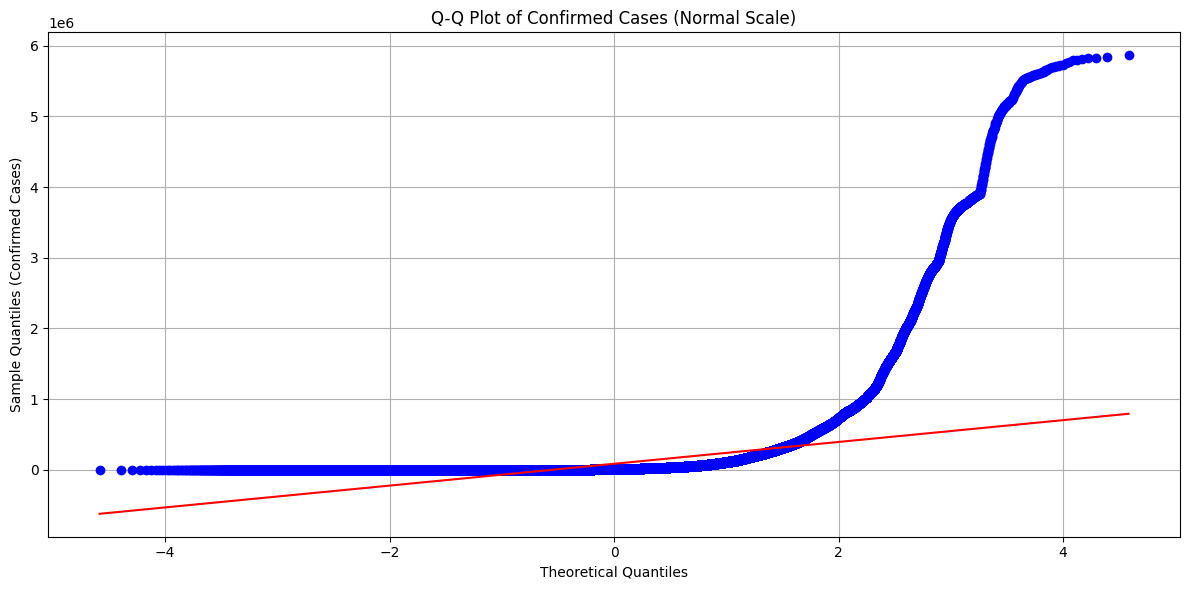

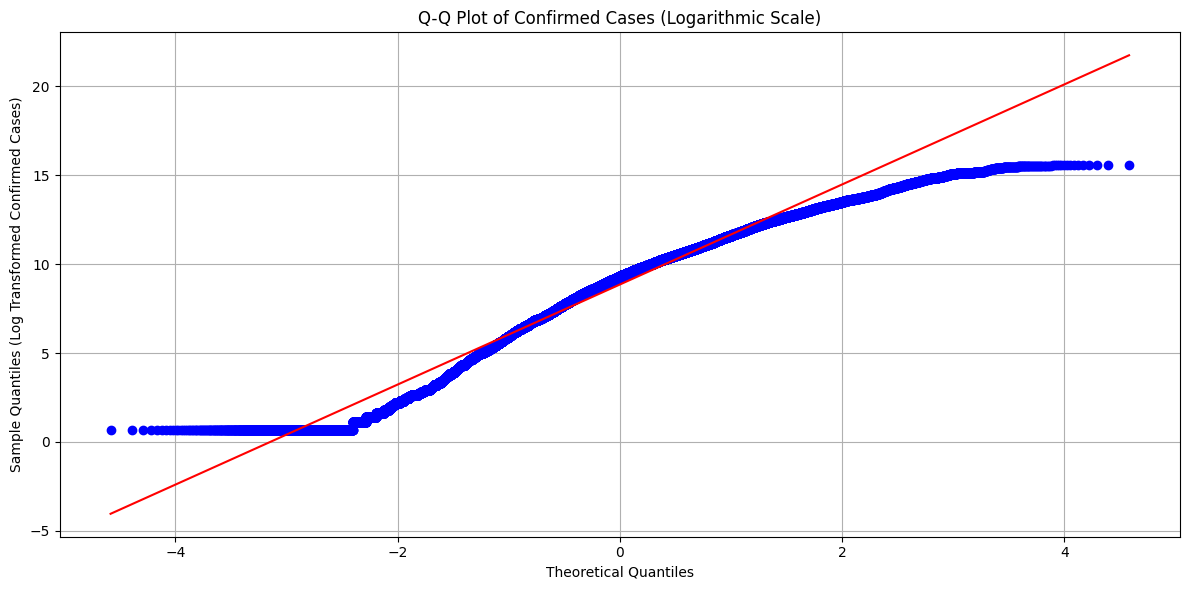

In [18]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# Get the 'Confirmed' cases data
# We should consider the final confirmed cases for each country/region for a single distribution analysis
# Or aggregate the data to a single series of unique confirmed case values across all entries
# For Q-Q plot, it is typically performed on a sample of data that represents a distribution.
# Let's take all unique confirmed case values from the entire dataframe to represent the overall distribution.
confirmed_cases = df['Confirmed'].loc[df['Confirmed'] > 0] # Filter out zeros for log scale and better distribution analysis

# --- Q-Q Plot for Confirmed Cases (Normal Scale) ---
plt.figure(figsize=(12, 6))
stats.probplot(confirmed_cases, dist="norm", plot=plt)
plt.title('Q-Q Plot of Confirmed Cases (Normal Scale)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles (Confirmed Cases)')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Q-Q Plot for Confirmed Cases (Logarithmic Scale) ---
plt.figure(figsize=(12, 6))
# Apply log transformation to confirmed cases
log_confirmed_cases = np.log(confirmed_cases + 1) # Add 1 to handle zero cases before log transformation
stats.probplot(log_confirmed_cases, dist="norm", plot=plt)
plt.title('Q-Q Plot of Confirmed Cases (Logarithmic Scale)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles (Log Transformed Confirmed Cases)')
plt.grid(True)
plt.tight_layout()
plt.show()

Pregunta: ¿Cómo se comportan los datos reales en comparación con las líneas teóricas?

Respuesta: Se comportan diferente, en los casos comfirmados es constante en 0 hasta llegar al quartil teorico 0 donde sube rapidamente hasta casi 6 casos confirmados.

En la escala logaritmica se ve que los casos confirmados transformados empiezan cerca del 1 y avanzan con constancia de -4 a -2, donde antes de llegar a -2 aumentan los casos confirmados con una curvatura hasta pasar lijeramente los 15 casos confirmados en el cuartil teorico 4.

## ACTIVIDAD 4: Análisis Visual Avanzado Mapa de Calor de Correlación

### 1. Mapa de Calor de Correlación:

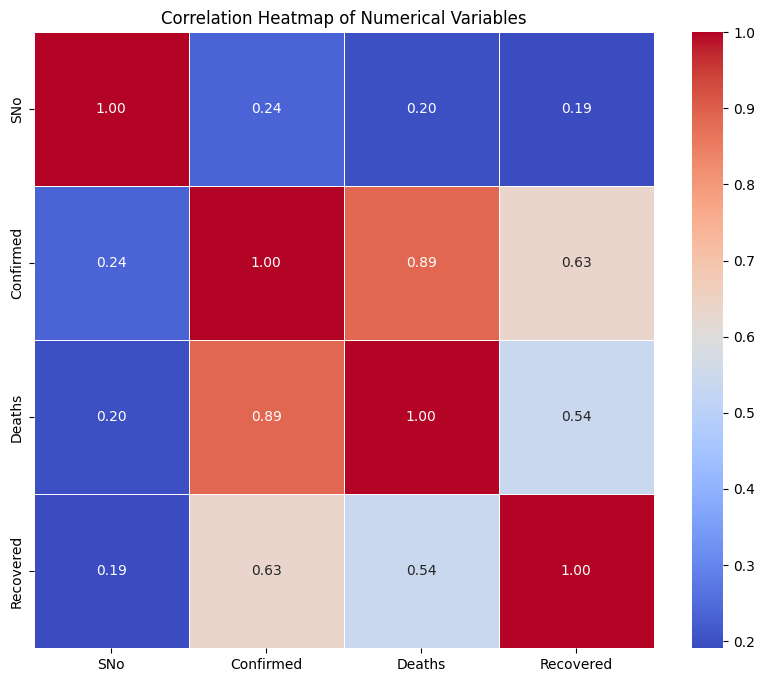

Pregunta: ¿Cuál es la correlación más fuerte?
Respuesta: La correlación más fuerte es entre 'Confirmed' y 'Deaths' con un valor de 0.89.


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

# Find the strongest correlation (excluding self-correlations)
# Convert to absolute values and fill diagonal with 0 to ignore self-correlation
abs_correlation_matrix = correlation_matrix.abs()
np.fill_diagonal(abs_correlation_matrix.values, 0)

# Find the maximum absolute correlation value
max_corr_value = abs_correlation_matrix.max().max()

# Find the corresponding variables for the strongest correlation
# Use stack() to convert to a Series, then get the index (multi-index of columns)
strongest_corr_pair = abs_correlation_matrix.stack().idxmax()

print("Pregunta: ¿Cuál es la correlación más fuerte?")
print(f"Respuesta: La correlación más fuerte es entre '{strongest_corr_pair[0]}' y '{strongest_corr_pair[1]}' con un valor de {correlation_matrix.loc[strongest_corr_pair[0], strongest_corr_pair[1]]:.2f}.")

### 2. Mapa de Calor Geográfico:

In [20]:
import plotly.express as px

# Aggregate data to get the total deaths per country
# We need the last cumulative value for deaths for each country
# First, ensure data is sorted by date to get the latest cumulative value correctly
df_sorted = df.sort_values(by=['Country/Region', 'ObservationDate'])

# Get the last entry for each country, which should represent the maximum cumulative values
latest_data_by_country = df_sorted.groupby('Country/Region').last().reset_index()

# Create the choropleth map
fig = px.choropleth(latest_data_by_country,
                    locations="Country/Region",
                    locationmode='country names',
                    color="Deaths",
                    hover_name="Country/Region",
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title='Global Distribution of COVID-19 Deaths by Country')

fig.show()


Pregunta: ¿Qué puede concluir acerca del gráfico?

Respuesta: Argentina, Iran y Polanda tuvieron el mayor numero de muertes por COVIT-19 registradas globalmente segun la grafica, mientras que paises como greenland, china y Peru tuvieron 0 muertes confirmadas por covit-19 y canada solo 2 muertes confirmadas por covit-19

## Discusión y Conclusiones
#### Basándose en todas las visualizaciones generadas, escriban las 3 conclusiones más importantes que se pueden extraer de los datos.


1. Hubo una fuerte correlacion entre casos confirmados y muertes segun el mapa de calor y el diagrama de dispersion, teniendo una relacion de aumento directamente proporcional.

2. Un impacto global desigual con la tasa de recuperacion, la grafica de barras y el mapa de calor geografico nos muestran que hay una distribucion desigual de casos, muertes y recuperaciones globalmente.

3. El diagrama de caja y bigote de casos confirmados no tenia una distribucion normal y requiere de transformacion de datos asi como logarithmic scaling, para un analisis mas preciso estadisticamente y modelado.